In [53]:
import numpy
import AILibs

dt = 1.0/250.0

num_samples = 1000
        

# system dynamics
#  state = [x, x_dot, theta, theta_dot]


A = [[ 1.00000e+00,  3.55800e-03,  0.00000e+00,  1.41800e-03],
 [-1.04500e-02,  8.10588e-01,  1.14918e-01,  6.91547e-01],
 [ 0.00000e+00,  0.00000e+00,  9.99958e-01,  3.66300e-03],
 [ 7.25000e-04,  0.00000e+00, -2.81530e-02,  8.50389e-01]]


B = [[ 1.18027000e+00, -7.62680000e-02],
 [ 5.45389216e+02, -3.68036210e+01],
 [-3.16000000e-04, 2.36700000e-02],
 [-6.34980000e-02,  1.13856510e+01]]


A = [   [ 1.0,        0.003455,  0.0,        0.0      ],
        [ 0.0,        0.769534,  0.0,        0.0      ],
        [ 0.0,        0.0,        1.0,        0.003628],
        [ 0.0,        0.0,       0.0,        0.838809]]

B = [[ 0.0,        0.0      ],
    [ 0.626173, -0.0      ],
    [ 0.0,        0.0      ],
    [-0.0,       11.464]]


A = numpy.array(A)
B = numpy.array(B)

#Q = numpy.diag([1.0, 0.0, 1.0, 0.0])
#R = numpy.diag([0.1, 10.0])  
#controller = AILibs.LQRDiscrete(A, B, Q, R, 10000.0)

Q = numpy.diag([1.0, 0.0, 1.0, 0.0])
R = numpy.diag([0.01, 10.0])  


controller = AILibs.LQRIDUDiscrete(A, B, Q, R, 1)


print("k = ", controller.k)     
print("ku = ", controller.ku)

# print as C arrays
def numpy_to_c_array(name, mat):
    mat = numpy.atleast_2d(mat)
    rows, cols = mat.shape
    print(f"const float {name}[{rows * cols}] = {{")
    for i in range(rows):
        row_str = ", ".join(f"{mat[i, j]:.6f}f" for j in range(cols))
        comma = "," if i < rows - 1 else ""
        print(f"    {row_str}{comma}")
    print("};")
    print()

print("\n\n")
numpy_to_c_array("lqr_k", controller.k)
numpy_to_c_array("lqr_ku", controller.ku)
    


k =  [[5.93580354e+00 8.10347126e-02 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.88902144e-01 3.72685662e-03]]
ku =  [[0.64766236 0.        ]
 [0.         0.6431598 ]]



const float lqr_k[8] = {
    5.935804f, 0.081035f, 0.000000f, 0.000000f,
    0.000000f, 0.000000f, 0.188902f, 0.003727f
};

const float lqr_ku[4] = {
    0.647662f, 0.000000f,
    0.000000f, 0.643160f
};



In [54]:
ds = AILibs.DynamicalSystemDiscrete(A, B, None)


x = ds.reset()

# 1m distance
d = 1.0

# 90 degrees
a = 90*numpy.pi/180.0

# desired states
xr_a = numpy.array([0.0, 0.0, 0.0, 0.0])
xr_b = numpy.array([d, 0.0, 0.0, 0.0])
xr_c = numpy.array([0.0, 0.0, a, 0.0])
xr_d = numpy.array([d, 0.0, a, 0.0])

# time step
t_result = []

# control inputs
u_result = []

# desired states
xr_result = []

# actual states
x_result = []

u = numpy.zeros((B.shape[1], 1))

for n in range(num_samples):

    # add zero state between different reference states
    
    if n < num_samples/5:
        xr = xr_a
    elif n < 2*num_samples/5:
        xr = xr_b
    elif n < 3*num_samples/5:
        xr = xr_a
    elif n < 4*num_samples/5:
        xr = xr_c
    else:
        xr = xr_d

    xr = numpy.expand_dims(xr, axis=1)

   

    u = controller.forward(xr, x, u)
    
    x, _ = ds.forward_state(u)

    t_result.append(n*dt)
    u_result.append(u)
    xr_result.append(xr)
    x_result.append(x)


t_result = numpy.array(t_result)
u_result = numpy.array(u_result)
xr_result = numpy.array(xr_result)
x_result = numpy.array(x_result)

print("done")

done


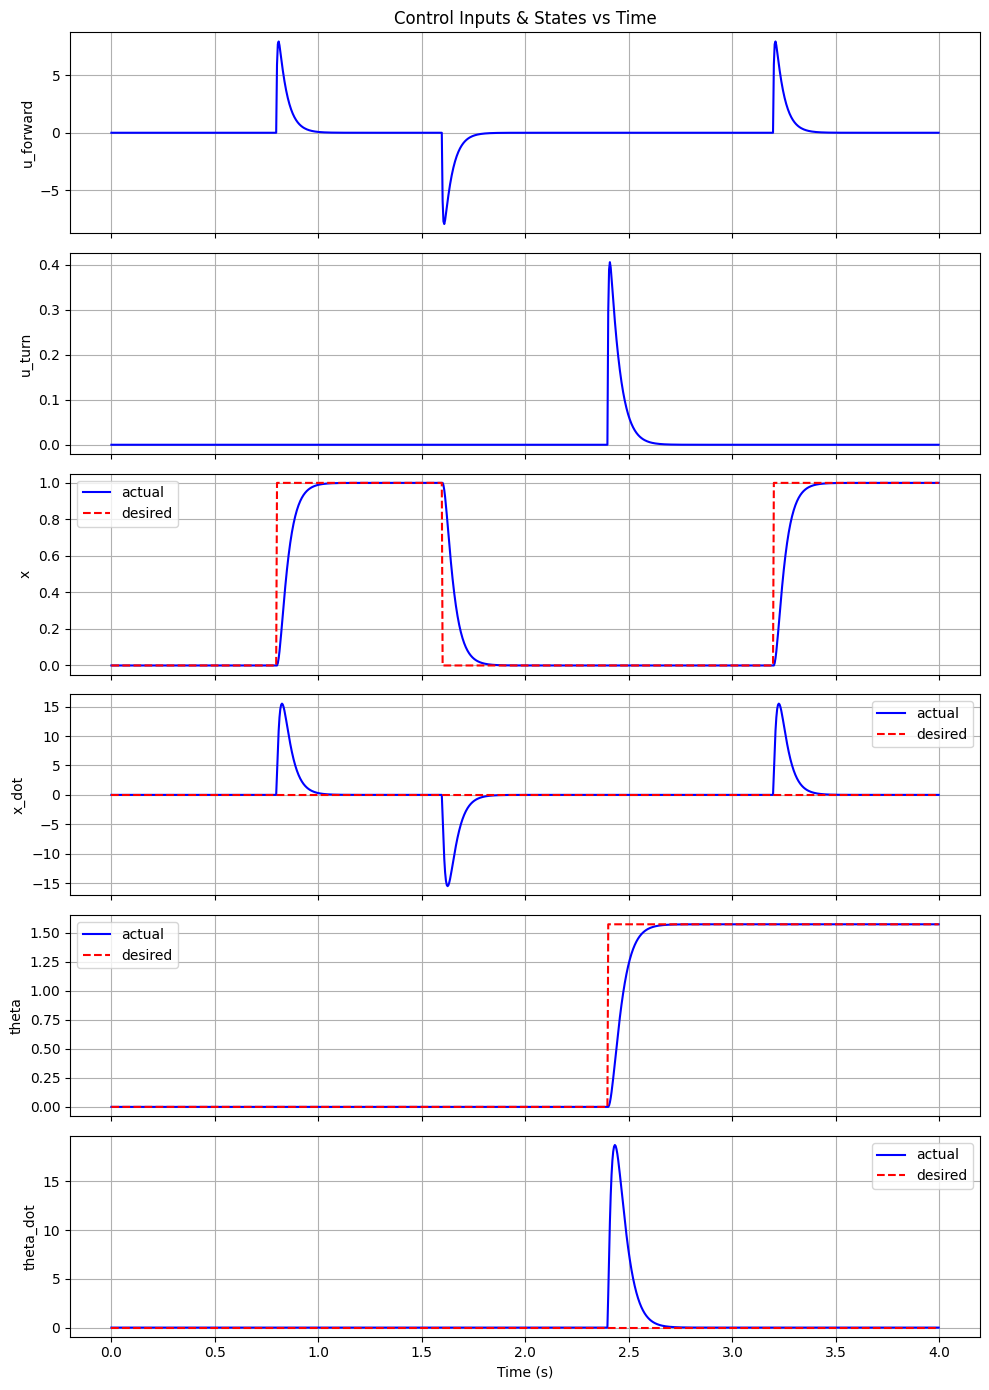

In [55]:
import matplotlib.pyplot as plt

control_labels  = ['u_forward', 'u_turn']
state_labels    = ['x', 'x_dot', 'theta', 'theta_dot']

fig, axes = plt.subplots(6, 1, figsize=(10, 14), sharex=True)

for i in range(2):
    axes[i].plot(t_result, u_result[:, i, 0], color='blue')
    axes[i].set_ylabel(control_labels[i])
    axes[i].grid()

for i in range(4):
    axes[i+2].plot(t_result, x_result[:, i], color='blue', label='actual')
    axes[i+2].plot(t_result, xr_result[:, i, 0], color='red', linestyle='dashed', label='desired')
    axes[i+2].set_ylabel(state_labels[i])
    axes[i+2].legend()
    axes[i+2].grid()

axes[-1].set_xlabel('Time (s)')
axes[0].set_title('Control Inputs & States vs Time')
plt.tight_layout()
plt.show()